In [1]:
import torch
import transformers
import sklearn
import pandas as pd

print(f"PyTorch version: {torch.__version__}")
print(f"Transformers version: {transformers.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM total: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    print(f"CUDA version: {torch.version.cuda}")
    print(f"Compute capability: {torch.cuda.get_device_capability(0)}")
else:
    print("⚠ CUDA NOT detected — check driver/install")

PyTorch version: 2.11.0+cu128
Transformers version: 5.8.0
CUDA available: True
GPU: NVIDIA GeForce RTX 5060 Ti
VRAM total: 16.61 GB
CUDA version: 12.8
Compute capability: (12, 0)


In [2]:
import pandas as pd

# Set display options so Bangla renders properly
pd.set_option('display.max_colwidth', 60)
pd.set_option('display.width', 200)

df = pd.read_csv("dyslex_probe_stimuli.csv")

print(f"Shape: {df.shape}")
print(f"Columns ({len(df.columns)}): {list(df.columns)}")
print()
print(f"By language:\n{df['language'].value_counts()}")
print()
print(f"By task_category:\n{df['task_category'].value_counts()}")

Shape: (400, 18)
Columns (18): ['id', 'language', 'task_category', 'word', 'ipa', 'syllable_count', 'phonological_complexity', 'orthographic_transparency', 'voiced_unvoiced', 'is_real_word', 'has_consonant_cluster', 'has_irregular_mapping', 'difficulty', 'pair_id', 'matched_pair_id', 'dissertation_source', 'error_type_targeted', 'notes']

By language:
language
english    200
bangla     200
Name: count, dtype: int64

By task_category:
task_category
minimal_pair        120
multisyllabic        60
pseudoword           50
real_word            50
phoneme_grapheme     50
rhyme                40
sentence             30
Name: count, dtype: int64


In [3]:
print("=== Bangla minimal pair samples ===")
print(df[df['language']=='bangla'].head(6)[['id', 'word', 'ipa', 'pair_id']].to_string(index=False))

print("\n=== Bangla multisyllabic samples ===")
print(df[(df['language']=='bangla') & (df['task_category']=='multisyllabic')].tail(5)[['word', 'ipa', 'syllable_count']].to_string(index=False))

print("\n=== Bangla sentence samples ===")
print(df[(df['language']=='bangla') & (df['task_category']=='sentence')].head(3)[['word']].to_string(index=False))

=== Bangla minimal pair samples ===
       id word  ipa        pair_id
MP_BN_061  কাল  kal PAIR_BN_VU_031
MP_BN_062  গাল  gal PAIR_BN_VU_031
MP_BN_063  পান  pan PAIR_BN_VU_032
MP_BN_064  বান  ban PAIR_BN_VU_032
MP_BN_065  তাল t̪al PAIR_BN_VU_033
MP_BN_066  দাল d̪al PAIR_BN_VU_033

=== Bangla multisyllabic samples ===
            word               ipa  syllable_count
  বিশ্ববিদ্যালয়  biʃʃobid̪d̪ʰalɔj               5
       প্রতিবেদন      prɔt̪ibed̪ɔn               4
      ব্যাকরণবিদ       bækɔrɔnbid̪               5
শিক্ষাপ্রতিষ্ঠান ʃikkʰaprɔt̪iʃʈʰan               5
  প্রকৃতিবিজ্ঞান  prɔkrit̪ibiggʰan               5

=== Bangla sentence samples ===
            word
    আমি বই পড়ি।
 সে স্কুলে যায়।
পাখি আকাশে ওড়ে।


In [4]:
print("Missing values per column:")
for col in df.columns:
    missing = df[col].isna().sum()
    print(f"  {col}: {missing} missing")

print(f"\nPair structure:")
print(f"  Items with pair_id: {df['pair_id'].notna().sum()}")
print(f"  Unique pairs: {df['pair_id'].dropna().nunique()}")

print(f"\nCross-lingual matches:")
xling = df[df['matched_pair_id'].notna() & (df['matched_pair_id'] != '')]
print(f"  Items with matched_pair_id: {len(xling)}")

Missing values per column:
  id: 0 missing
  language: 0 missing
  task_category: 0 missing
  word: 0 missing
  ipa: 30 missing
  syllable_count: 0 missing
  phonological_complexity: 0 missing
  orthographic_transparency: 0 missing
  voiced_unvoiced: 0 missing
  is_real_word: 0 missing
  has_consonant_cluster: 0 missing
  has_irregular_mapping: 0 missing
  difficulty: 0 missing
  pair_id: 240 missing
  matched_pair_id: 385 missing
  dissertation_source: 0 missing
  error_type_targeted: 0 missing
  notes: 0 missing

Pair structure:
  Items with pair_id: 160
  Unique pairs: 80

Cross-lingual matches:
  Items with matched_pair_id: 15


In [5]:
# Replace NaN with empty string in string columns for cleaner downstream processing
str_cols = ['ipa', 'pair_id', 'matched_pair_id', 'dissertation_source', 'error_type_targeted', 'notes']
for col in str_cols:
    df[col] = df[col].fillna('')

df.to_csv("dyslex_probe_stimuli_clean.csv", index=False, encoding="utf-8")
print(f"Saved clean version: {df.shape}")

Saved clean version: (400, 18)


In [6]:
import torch
from transformers import AutoTokenizer, AutoModel
import pandas as pd
import numpy as np

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

MODEL_NAME = "xlm-roberta-large"

print(f"Loading tokenizer for {MODEL_NAME}...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print(f"Loading model {MODEL_NAME}...")
model = AutoModel.from_pretrained(MODEL_NAME, output_hidden_states=True)
model = model.to(device)
model.eval()

print(f"\nModel loaded successfully.")
print(f"Hidden size: {model.config.hidden_size}")
print(f"Number of layers: {model.config.num_hidden_layers}")
print(f"VRAM used: {torch.cuda.memory_allocated() / 1e9:.2f} GB")

Using device: cuda
Loading tokenizer for xlm-roberta-large...


Loading model xlm-roberta-large...


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

[transformers] XLMRobertaModel LOAD REPORT from: xlm-roberta-large
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Model loaded successfully.
Hidden size: 1024
Number of layers: 24
VRAM used: 2.24 GB


In [7]:
def extract_representation(text, model, tokenizer, device):
    """
    Extract hidden states from all layers for a single text.
    Returns numpy array of shape (num_layers + 1, hidden_dim)
    where +1 includes the embedding layer.
    """
    # Tokenize
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=512)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    
    # Forward pass
    with torch.no_grad():
        outputs = model(**inputs, output_hidden_states=True)
    
    # outputs.hidden_states is a tuple of (num_layers + 1) tensors,
    # each shape (batch=1, seq_len, hidden_dim)
    hidden_states = outputs.hidden_states  # tuple of 25 tensors for XLM-R-large
    
    # For each layer: mean-pool across content tokens (exclude special tokens)
    # XLM-R uses <s> at start and </s> at end
    attention_mask = inputs["attention_mask"][0]  # shape (seq_len,)
    
    # Mask out special tokens by masking first and last positions
    content_mask = attention_mask.clone()
    content_mask[0] = 0  # exclude <s>
    # find position of </s> (last non-pad token)
    last_idx = (attention_mask == 1).nonzero()[-1].item()
    content_mask[last_idx] = 0  # exclude </s>
    
    pooled_layers = []
    for layer_hidden in hidden_states:
        # layer_hidden shape: (1, seq_len, hidden_dim)
        layer = layer_hidden[0]  # (seq_len, hidden_dim)
        # Mean pool over content tokens
        masked = layer * content_mask.unsqueeze(-1).float()
        pooled = masked.sum(dim=0) / content_mask.sum().clamp(min=1).float()
        pooled_layers.append(pooled.cpu().numpy())
    
    return np.stack(pooled_layers)  # shape (num_layers+1, hidden_dim)

print("Function defined.")

Function defined.


In [8]:
df = pd.read_csv("dyslex_probe_stimuli_clean.csv")

# Pick 5 test stimuli: 2 English single words, 2 Bangla single words, 1 Bangla multisyllabic with conjunct
test_ids = ['MP_EN_001', 'PW_EN_001', 'MP_BN_061', 'PW_BN_001', 'MS_BN_030']
test_df = df[df['id'].isin(test_ids)].copy()

print(f"Test stimuli ({len(test_df)}):")
print(test_df[['id', 'language', 'task_category', 'word']].to_string(index=False))
print()

# Extract representations
representations = []
for _, row in test_df.iterrows():
    rep = extract_representation(row['word'], model, tokenizer, device)
    representations.append(rep)
    print(f"  {row['id']:12s} word={row['word']:20s} shape={rep.shape}  mean={rep.mean():+.4f}  std={rep.std():.4f}")

representations = np.stack(representations)
print(f"\nStacked shape: {representations.shape}")
print(f"Expected: (5, 25, 1024)  [5 stimuli, 25 layers including embeddings, hidden_dim 1024]")

Test stimuli (5):
       id language task_category           word
MP_EN_001  english  minimal_pair            bat
MP_BN_061   bangla  minimal_pair            কাল
PW_EN_001  english    pseudoword           blip
PW_BN_001   bangla    pseudoword           নিদা
MS_BN_030   bangla multisyllabic প্রকৃতিবিজ্ঞান

  MP_EN_001    word=bat                  shape=(25, 1024)  mean=+0.0137  std=0.9375
  MP_BN_061    word=কাল                  shape=(25, 1024)  mean=+0.0135  std=0.9428
  PW_EN_001    word=blip                 shape=(25, 1024)  mean=+0.0138  std=0.8896
  PW_BN_001    word=নিদা                 shape=(25, 1024)  mean=+0.0125  std=0.9074
  MS_BN_030    word=প্রকৃতিবিজ্ঞান       shape=(25, 1024)  mean=+0.0136  std=0.9086

Stacked shape: (5, 25, 1024)
Expected: (5, 25, 1024)  [5 stimuli, 25 layers including embeddings, hidden_dim 1024]


In [9]:
# Check that representations are meaningfully different across stimuli
# Cosine similarity at the final layer between every pair of test stimuli
from sklearn.metrics.pairwise import cosine_similarity

final_layer = representations[:, -1, :]  # shape (5, 1024) — last layer
sim_matrix = cosine_similarity(final_layer)

print("Cosine similarity at final layer:")
print(f"{'':12s}", end="")
for i, id_ in enumerate(test_df['id'].values):
    print(f"{id_:>12s}", end="")
print()
for i, id_ in enumerate(test_df['id'].values):
    print(f"{id_:12s}", end="")
    for j in range(len(test_df)):
        print(f"{sim_matrix[i,j]:>12.3f}", end="")
    print()

print("\nSanity check:")
print(f"  Self-similarity (should be 1.0): {sim_matrix[0,0]:.4f}")
print(f"  English-English (bat vs blip):  {sim_matrix[0,1]:.4f}")
print(f"  English-Bangla (bat vs কাল):    {sim_matrix[0,2]:.4f}")
print(f"  Bangla-Bangla (কাল vs নিদা):   {sim_matrix[2,3]:.4f}")

Cosine similarity at final layer:
               MP_EN_001   MP_BN_061   PW_EN_001   PW_BN_001   MS_BN_030
MP_EN_001          1.000       0.976       0.982       0.950       0.972
MP_BN_061          0.976       1.000       0.989       0.967       0.989
PW_EN_001          0.982       0.989       1.000       0.962       0.986
PW_BN_001          0.950       0.967       0.962       1.000       0.968
MS_BN_030          0.972       0.989       0.986       0.968       1.000

Sanity check:
  Self-similarity (should be 1.0): 1.0000
  English-English (bat vs blip):  0.9755
  English-Bangla (bat vs কাল):    0.9816
  Bangla-Bangla (কাল vs নিদা):   0.9624


In [10]:
# Check similarity at multiple layers to confirm middle layers are more discriminative
print("Cross-script similarity (bat vs কাল) across layers:")
print(f"{'Layer':<8}{'Cosine sim':<12}")
for layer_idx in [0, 4, 8, 12, 16, 20, 24]:
    en = representations[0, layer_idx, :].reshape(1, -1)
    bn = representations[2, layer_idx, :].reshape(1, -1)
    sim = cosine_similarity(en, bn)[0, 0]
    print(f"{layer_idx:<8}{sim:<12.4f}")

print("\nWithin-language similarity (bat vs blip) across layers:")
for layer_idx in [0, 4, 8, 12, 16, 20, 24]:
    en1 = representations[0, layer_idx, :].reshape(1, -1)
    en2 = representations[1, layer_idx, :].reshape(1, -1)
    sim = cosine_similarity(en1, en2)[0, 0]
    print(f"{layer_idx:<8}{sim:<12.4f}")

Cross-script similarity (bat vs কাল) across layers:
Layer   Cosine sim  
0       0.2242      
4       0.7670      
8       0.8971      
12      0.8736      
16      0.9002      
20      0.9084      
24      0.9816      

Within-language similarity (bat vs blip) across layers:
0       0.0603      
4       0.7262      
8       0.8363      
12      0.8227      
16      0.8349      
20      0.8414      
24      0.9756      


In [11]:
from tqdm.auto import tqdm
import os

os.makedirs("representations", exist_ok=True)

df = pd.read_csv("dyslex_probe_stimuli_clean.csv")

# Storage: separate arrays per language
en_df = df[df['language'] == 'english'].reset_index(drop=True)
bn_df = df[df['language'] == 'bangla'].reset_index(drop=True)

print(f"English stimuli: {len(en_df)}")
print(f"Bangla stimuli: {len(bn_df)}")

# Extract English
print("\nExtracting English representations...")
en_reps = []
for _, row in tqdm(en_df.iterrows(), total=len(en_df), desc="English"):
    rep = extract_representation(row['word'], model, tokenizer, device)
    en_reps.append(rep)
en_reps = np.stack(en_reps)

# Extract Bangla
print("\nExtracting Bangla representations...")
bn_reps = []
for _, row in tqdm(bn_df.iterrows(), total=len(bn_df), desc="Bangla"):
    rep = extract_representation(row['word'], model, tokenizer, device)
    bn_reps.append(rep)
bn_reps = np.stack(bn_reps)

# Save everything
np.save("representations/xlmr_english_reps.npy", en_reps)
np.save("representations/xlmr_bangla_reps.npy", bn_reps)
en_df.to_csv("representations/xlmr_english_meta.csv", index=False, encoding="utf-8")
bn_df.to_csv("representations/xlmr_bangla_meta.csv", index=False, encoding="utf-8")

print(f"\nSaved:")
print(f"  English: shape {en_reps.shape}  →  representations/xlmr_english_reps.npy")
print(f"  Bangla:  shape {bn_reps.shape}  →  representations/xlmr_bangla_reps.npy")
print(f"  File sizes: ~{(en_reps.nbytes + bn_reps.nbytes) / 1e6:.1f} MB")

English stimuli: 200
Bangla stimuli: 200

Extracting English representations...


English:   0%|          | 0/200 [00:00<?, ?it/s]


Extracting Bangla representations...


Bangla:   0%|          | 0/200 [00:00<?, ?it/s]


Saved:
  English: shape (200, 25, 1024)  →  representations/xlmr_english_reps.npy
  Bangla:  shape (200, 25, 1024)  →  representations/xlmr_bangla_reps.npy
  File sizes: ~41.0 MB


In [12]:
# Quick sanity check on saved files
en_check = np.load("representations/xlmr_english_reps.npy")
bn_check = np.load("representations/xlmr_bangla_reps.npy")

print(f"English: shape {en_check.shape}, dtype {en_check.dtype}")
print(f"Bangla:  shape {bn_check.shape}, dtype {bn_check.dtype}")
print(f"Any NaN in English?  {np.isnan(en_check).any()}")
print(f"Any NaN in Bangla?   {np.isnan(bn_check).any()}")
print(f"English value range: [{en_check.min():.3f}, {en_check.max():.3f}]")
print(f"Bangla value range:  [{bn_check.min():.3f}, {bn_check.max():.3f}]")

English: shape (200, 25, 1024), dtype float32
Bangla:  shape (200, 25, 1024), dtype float32
Any NaN in English?  False
Any NaN in Bangla?   False
English value range: [-30.904, 28.669]
Bangla value range:  [-31.011, 28.836]


In [13]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.model_selection import StratifiedKFold, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings("ignore")

# Reload data
en_reps = np.load("representations/xlmr_english_reps.npy")
bn_reps = np.load("representations/xlmr_bangla_reps.npy")
en_meta = pd.read_csv("representations/xlmr_english_meta.csv")
bn_meta = pd.read_csv("representations/xlmr_bangla_meta.csv")

print(f"English reps: {en_reps.shape}")
print(f"Bangla reps:  {bn_reps.shape}")
print(f"Num layers: {en_reps.shape[1]}")
print(f"Hidden dim: {en_reps.shape[2]}")

# Check label distributions for each probing task on English data
print("\n=== Label availability (English) ===")
print(f"voiced_unvoiced:")
print(en_meta['voiced_unvoiced'].value_counts())
print(f"\nis_real_word:")
print(en_meta['is_real_word'].value_counts())
print(f"\northographic_transparency:")
print(en_meta['orthographic_transparency'].value_counts())
print(f"\nsyllable_count range: {en_meta['syllable_count'].min()} to {en_meta['syllable_count'].max()}")
print(en_meta['syllable_count'].value_counts().sort_index())

English reps: (200, 25, 1024)
Bangla reps:  (200, 25, 1024)
Num layers: 25
Hidden dim: 1024

=== Label availability (English) ===
voiced_unvoiced:
voiced_unvoiced
na          170
voiced       15
unvoiced     15
Name: count, dtype: int64

is_real_word:
is_real_word
True     175
False     25
Name: count, dtype: int64

orthographic_transparency:
orthographic_transparency
transparent    162
opaque          38
Name: count, dtype: int64

syllable_count range: 1 to 8
syllable_count
1    119
2     31
3     20
4     11
5      8
6      4
7      3
8      4
Name: count, dtype: int64


In [14]:
from sklearn.metrics import f1_score, accuracy_score
from sklearn.model_selection import cross_val_score, cross_validate

NUM_LAYERS = en_reps.shape[1]  # 25

# Define probing tasks
# Each entry: (task_name, label_column, problem_type, filter_fn)
# filter_fn returns a boolean mask of which rows to include
def filter_voicing(meta):
    return meta['voiced_unvoiced'].isin(['voiced', 'unvoiced'])

def filter_realword(meta):
    # Only include single-word categories (not sentences)
    return meta['task_category'].isin(['pseudoword', 'real_word'])

def filter_transparency(meta):
    return meta['task_category'].isin(['phoneme_grapheme'])  # only this category has clean labels

def filter_syllables(meta):
    # Exclude sentences for syllable count probing
    return meta['task_category'] != 'sentence'

tasks = [
    ('voiced_unvoiced', 'voiced_unvoiced', 'classification', filter_voicing),
    ('is_real_word', 'is_real_word', 'classification', filter_realword),
    ('orthographic_transparency', 'orthographic_transparency', 'classification', filter_transparency),
    ('syllable_count', 'syllable_count', 'regression', filter_syllables),
]

results = []

for task_name, label_col, ptype, filter_fn in tasks:
    mask = filter_fn(en_meta).values
    n_samples = mask.sum()
    print(f"\n=== Task: {task_name} ({ptype}) ===")
    print(f"  Samples used: {n_samples}")
    
    if n_samples < 20:
        print(f"  ⚠ Too few samples — skipping")
        continue
    
    y = en_meta.loc[mask, label_col].values
    
    if ptype == 'classification':
        print(f"  Class distribution: {dict(pd.Series(y).value_counts())}")
        # Choose CV: stratified if classification
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    else:
        cv = KFold(n_splits=5, shuffle=True, random_state=42)
    
    # Train probe per layer
    for layer in range(NUM_LAYERS):
        X = en_reps[mask, layer, :]  # (n_samples, 1024)
        
        # Standardize features per layer
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
        
        if ptype == 'classification':
            probe = LogisticRegression(max_iter=2000, C=1.0, random_state=42)
            scores = cross_val_score(probe, X_scaled, y, cv=cv, scoring='f1_macro')
        else:
            probe = Ridge(alpha=1.0, random_state=42)
            scores = cross_val_score(probe, X_scaled, y, cv=cv, scoring='r2')
        
        results.append({
            'task': task_name,
            'layer': layer,
            'mean_score': scores.mean(),
            'std_score': scores.std(),
            'metric': 'f1_macro' if ptype == 'classification' else 'r2',
            'n_samples': n_samples,
        })

results_df = pd.DataFrame(results)
results_df.to_csv("results_english_probing.csv", index=False)

# Show best layer per task
print("\n=== Best layer per task (English) ===")
best = results_df.loc[results_df.groupby('task')['mean_score'].idxmax()]
print(best[['task', 'layer', 'mean_score', 'std_score', 'metric', 'n_samples']].to_string(index=False))


=== Task: voiced_unvoiced (classification) ===
  Samples used: 30
  Class distribution: {'voiced': np.int64(15), 'unvoiced': np.int64(15)}

=== Task: is_real_word (classification) ===
  Samples used: 50
  Class distribution: {False: np.int64(25), True: np.int64(25)}

=== Task: orthographic_transparency (classification) ===
  Samples used: 25
  Class distribution: {'opaque': np.int64(13), 'transparent': np.int64(12)}

=== Task: syllable_count (regression) ===
  Samples used: 185

=== Best layer per task (English) ===
                     task  layer  mean_score  std_score   metric  n_samples
             is_real_word     11    0.837525   0.103386 f1_macro         50
orthographic_transparency      0    0.920000   0.097980 f1_macro         25
           syllable_count      8    0.673658   0.095861       r2        185
          voiced_unvoiced     11    0.618333   0.127872 f1_macro         30


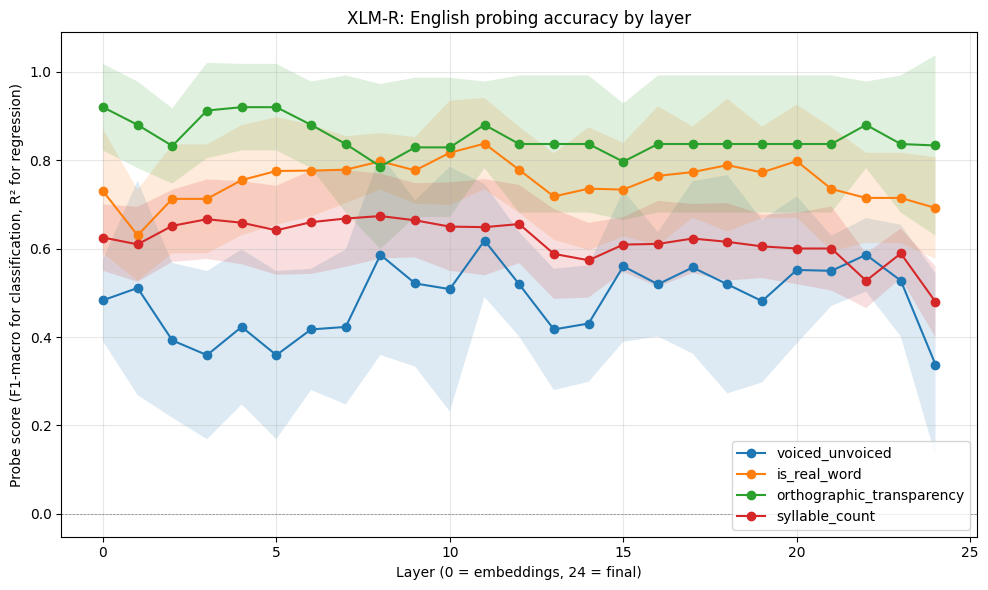

In [15]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))
for task in results_df['task'].unique():
    sub = results_df[results_df['task'] == task]
    ax.plot(sub['layer'], sub['mean_score'], marker='o', label=task)
    ax.fill_between(sub['layer'],
                     sub['mean_score'] - sub['std_score'],
                     sub['mean_score'] + sub['std_score'],
                     alpha=0.15)

ax.axhline(0, color='gray', linestyle='--', linewidth=0.5)
ax.set_xlabel('Layer (0 = embeddings, 24 = final)')
ax.set_ylabel('Probe score (F1-macro for classification, R² for regression)')
ax.set_title('XLM-R: English probing accuracy by layer')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("plots_english_probing.png", dpi=150, bbox_inches='tight')
plt.show()

In [17]:
from sklearn.metrics import f1_score, r2_score
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.preprocessing import StandardScaler

# ─── FIX: Add proper voiced_unvoiced labels to Bangla minimal pairs ───
# In the original CSV, Bangla voicing pairs were marked "na". Restore the labels
# based on the error_type_targeted column.

# Set of Bangla letters that START a voiced stop/affricate
voiced_starters = {'গ', 'ব', 'দ', 'ড', 'জ', 'ঘ', 'ভ', 'ধ', 'ঢ', 'ঝ'}
unvoiced_starters = {'ক', 'প', 'ত', 'ট', 'চ', 'খ', 'ফ', 'থ', 'ঠ', 'ছ'}

def infer_bn_voicing(row):
    if row['language'] != 'bangla':
        return row['voiced_unvoiced']
    if row['error_type_targeted'] not in ('voiced_unvoiced_confusion', 'aspiration_confusion'):
        return row['voiced_unvoiced']
    first_char = row['word'][0]
    if first_char in voiced_starters:
        return 'voiced'
    if first_char in unvoiced_starters:
        return 'unvoiced'
    return 'na'

bn_meta['voiced_unvoiced'] = bn_meta.apply(infer_bn_voicing, axis=1)

print("Bangla voicing labels after fix:")
print(bn_meta['voiced_unvoiced'].value_counts())

# ─── Filters ───
def filter_voicing(meta):
    return meta['voiced_unvoiced'].isin(['voiced', 'unvoiced'])

def filter_realword(meta):
    return meta['task_category'].isin(['pseudoword', 'real_word'])

def filter_syllables(meta):
    return meta['task_category'] != 'sentence'

transfer_tasks = [
    ('voiced_unvoiced', 'voiced_unvoiced', 'classification', filter_voicing, filter_voicing),
    ('is_real_word', 'is_real_word', 'classification', filter_realword, filter_realword),
    ('syllable_count', 'syllable_count', 'regression', filter_syllables, filter_syllables),
]

transfer_results = []

for task_name, label_col, ptype, en_filter, bn_filter in transfer_tasks:
    en_mask = en_filter(en_meta).values
    bn_mask = bn_filter(bn_meta).values
    
    print(f"\n=== Transfer task: {task_name} ===")
    print(f"  English training samples: {en_mask.sum()}")
    print(f"  Bangla test samples:      {bn_mask.sum()}")
    
    if en_mask.sum() == 0 or bn_mask.sum() == 0:
        print(f"  ⚠ Skipping — empty set on one side")
        continue
    
    y_en = en_meta.loc[en_mask, label_col].values
    y_bn = bn_meta.loc[bn_mask, label_col].values
    
    if ptype == 'classification':
        print(f"  English class distribution: {dict(pd.Series(y_en).value_counts())}")
        print(f"  Bangla class distribution:  {dict(pd.Series(y_bn).value_counts())}")
    
    for layer in range(NUM_LAYERS):
        X_en = en_reps[en_mask, layer, :]
        X_bn = bn_reps[bn_mask, layer, :]
        
        scaler = StandardScaler()
        X_en_scaled = scaler.fit_transform(X_en)
        X_bn_scaled = scaler.transform(X_bn)
        
        if ptype == 'classification':
            probe = LogisticRegression(max_iter=2000, C=1.0, random_state=42)
            probe.fit(X_en_scaled, y_en)
            en_pred = probe.predict(X_en_scaled)
            bn_pred = probe.predict(X_bn_scaled)
            en_score = f1_score(y_en, en_pred, average='macro')
            bn_score = f1_score(y_bn, bn_pred, average='macro')
            metric = 'f1_macro'
        else:
            probe = Ridge(alpha=1.0, random_state=42)
            probe.fit(X_en_scaled, y_en)
            en_pred = probe.predict(X_en_scaled)
            bn_pred = probe.predict(X_bn_scaled)
            en_score = r2_score(y_en, en_pred)
            bn_score = r2_score(y_bn, bn_pred)
            metric = 'r2'
        
        transfer_ratio = bn_score / en_score if en_score > 0 else 0
        
        transfer_results.append({
            'task': task_name,
            'layer': layer,
            'english_score': en_score,
            'bangla_score': bn_score,
            'transfer_ratio': transfer_ratio,
            'metric': metric,
        })

transfer_df = pd.DataFrame(transfer_results)
transfer_df.to_csv("results_transfer.csv", index=False)

# Best transfer per task
print("\n=== Best Bangla transfer per task ===")
best_transfer = transfer_df.loc[transfer_df.groupby('task')['bangla_score'].idxmax()]
print(best_transfer[['task', 'layer', 'english_score', 'bangla_score', 'transfer_ratio', 'metric']].to_string(index=False))

# Also save corrected Bangla metadata for later steps
bn_meta.to_csv("representations/xlmr_bangla_meta.csv", index=False, encoding="utf-8")

Bangla voicing labels after fix:
voiced_unvoiced
na          154
unvoiced     23
voiced       23
Name: count, dtype: int64

=== Transfer task: voiced_unvoiced ===
  English training samples: 30
  Bangla test samples:      46
  English class distribution: {'voiced': np.int64(15), 'unvoiced': np.int64(15)}
  Bangla class distribution:  {'unvoiced': np.int64(23), 'voiced': np.int64(23)}

=== Transfer task: is_real_word ===
  English training samples: 50
  Bangla test samples:      50
  English class distribution: {False: np.int64(25), True: np.int64(25)}
  Bangla class distribution:  {False: np.int64(25), True: np.int64(25)}

=== Transfer task: syllable_count ===
  English training samples: 185
  Bangla test samples:      185

=== Best Bangla transfer per task ===
           task  layer  english_score  bangla_score  transfer_ratio   metric
   is_real_word      6       1.000000      0.702886        0.702886 f1_macro
 syllable_count     11       0.999998      0.519335        0.519336       

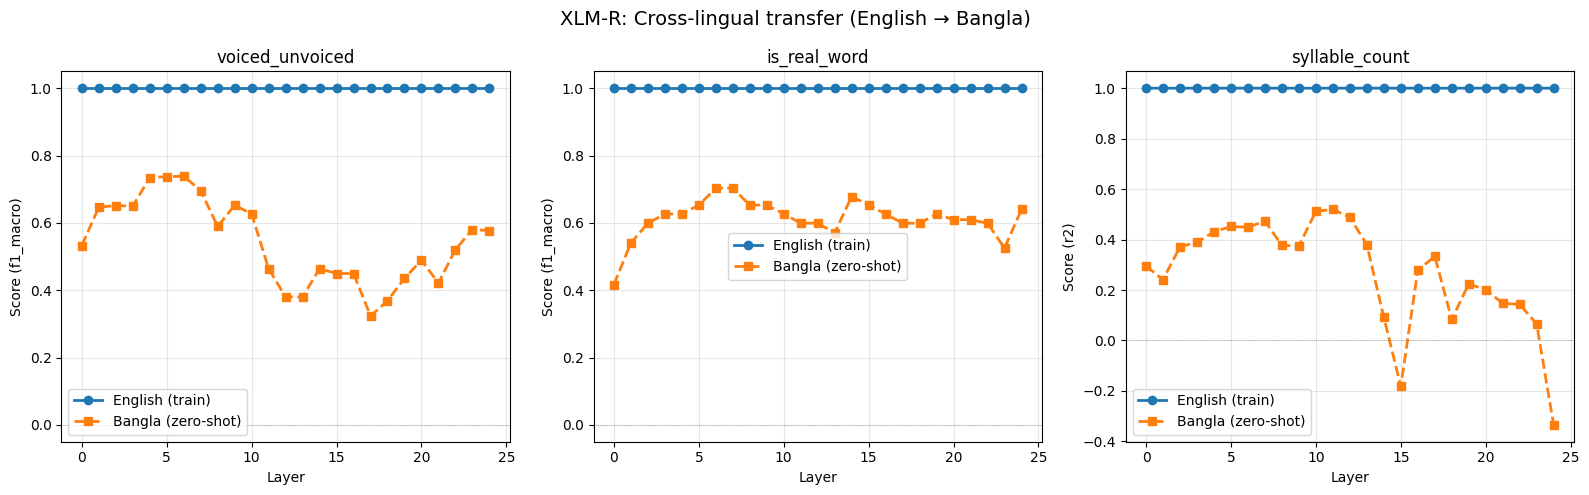

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, task in enumerate(transfer_df['task'].unique()):
    sub = transfer_df[transfer_df['task'] == task]
    ax = axes[i]
    ax.plot(sub['layer'], sub['english_score'], marker='o', label='English (train)', linewidth=2)
    ax.plot(sub['layer'], sub['bangla_score'], marker='s', label='Bangla (zero-shot)', linewidth=2, linestyle='--')
    ax.axhline(0, color='gray', linestyle=':', linewidth=0.5)
    ax.set_xlabel('Layer')
    metric_name = sub['metric'].iloc[0]
    ax.set_ylabel(f'Score ({metric_name})')
    ax.set_title(f'{task}')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('XLM-R: Cross-lingual transfer (English → Bangla)', fontsize=14)
plt.tight_layout()
plt.savefig("plots_transfer.png", dpi=150, bbox_inches='tight')
plt.show()

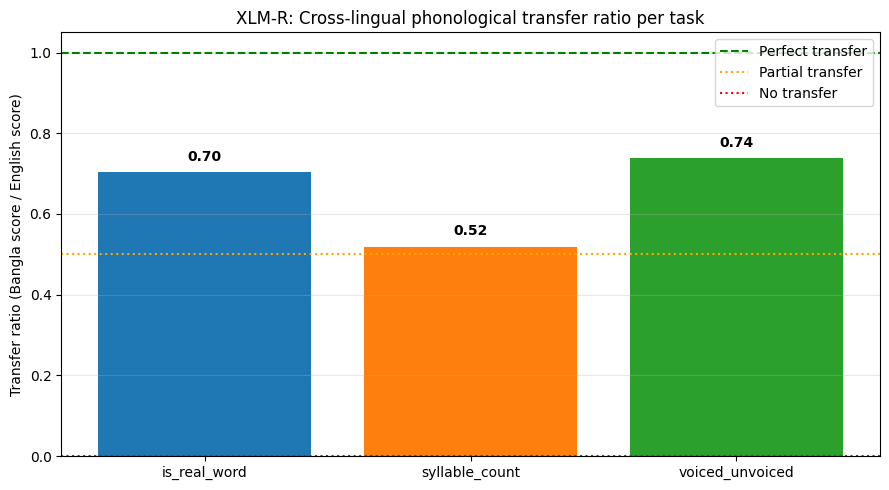

In [19]:
# For each task, show the transfer ratio at the best Bangla layer
best_transfer_layers = transfer_df.loc[transfer_df.groupby('task')['bangla_score'].idxmax()].copy()

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
bars = ax.bar(best_transfer_layers['task'], best_transfer_layers['transfer_ratio'], color=colors)
ax.axhline(1.0, color='green', linestyle='--', label='Perfect transfer')
ax.axhline(0.5, color='orange', linestyle=':', label='Partial transfer')
ax.axhline(0, color='red', linestyle=':', label='No transfer')
ax.set_ylabel('Transfer ratio (Bangla score / English score)')
ax.set_title('XLM-R: Cross-lingual phonological transfer ratio per task')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3, axis='y')

for bar, ratio in zip(bars, best_transfer_layers['transfer_ratio']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{ratio:.2f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig("plots_transfer_ratio.png", dpi=150, bbox_inches='tight')
plt.show()

In [23]:
# Re-load extended dataset
df_extended = pd.read_csv("dyslex_probe_stimuli_clean.csv")
print(f"Extended dataset size: {len(df_extended)}")

# Get just the new rows (the ones we haven't extracted yet)
new_rows = df_extended[df_extended['task_category'] == 'concept_match'].copy()
print(f"New concept-match rows to extract: {len(new_rows)}")

en_new = new_rows[new_rows['language'] == 'english'].reset_index(drop=True)
bn_new = new_rows[new_rows['language'] == 'bangla'].reset_index(drop=True)

print(f"  New English: {len(en_new)}")
print(f"  New Bangla:  {len(bn_new)}")

# Extract using existing function and model (already loaded)
print("\nExtracting new English representations...")
en_new_reps = np.stack([extract_representation(w, model, tokenizer, device) 
                        for w in tqdm(en_new['word'].values)])

print("Extracting new Bangla representations...")
bn_new_reps = np.stack([extract_representation(w, model, tokenizer, device) 
                        for w in tqdm(bn_new['word'].values)])

# Append to existing representation arrays
en_reps = np.load("representations/xlmr_english_reps.npy")
bn_reps = np.load("representations/xlmr_bangla_reps.npy")

en_reps_ext = np.concatenate([en_reps, en_new_reps], axis=0)
bn_reps_ext = np.concatenate([bn_reps, bn_new_reps], axis=0)

# Update metadata
en_meta_ext = pd.concat([en_meta, en_new], ignore_index=True)
bn_meta_ext = pd.concat([bn_meta, bn_new], ignore_index=True)

# Save extended versions
np.save("representations/xlmr_english_reps.npy", en_reps_ext)
np.save("representations/xlmr_bangla_reps.npy", bn_reps_ext)
en_meta_ext.to_csv("representations/xlmr_english_meta.csv", index=False, encoding="utf-8")
bn_meta_ext.to_csv("representations/xlmr_bangla_meta.csv", index=False, encoding="utf-8")

# Update in-memory variables for downstream cells
en_reps = en_reps_ext
bn_reps = bn_reps_ext
en_meta = en_meta_ext
bn_meta = bn_meta_ext

print(f"\nExtended representations:")
print(f"  English: {en_reps.shape}")
print(f"  Bangla:  {bn_reps.shape}")

Extended dataset size: 440
New concept-match rows to extract: 40
  New English: 20
  New Bangla:  20

Extracting new English representations...


  0%|          | 0/20 [00:00<?, ?it/s]

Extracting new Bangla representations...


  0%|          | 0/20 [00:00<?, ?it/s]


Extended representations:
  English: (220, 25, 1024)
  Bangla:  (220, 25, 1024)


In [24]:
from sklearn.metrics.pairwise import cosine_similarity

# Find cross-lingual matched pairs
xling_en = en_meta[en_meta['matched_pair_id'].notna() & (en_meta['matched_pair_id'] != '')].copy()
xling_bn = bn_meta[bn_meta['matched_pair_id'].notna() & (bn_meta['matched_pair_id'] != '')].copy()

# Merge to get aligned indices
matched = pd.merge(
    xling_en[['matched_pair_id', 'word']].rename(columns={'word': 'en_word'}),
    xling_bn[['matched_pair_id', 'word']].rename(columns={'word': 'bn_word'}),
    on='matched_pair_id'
)

# Get the original row positions (indices in en_meta / bn_meta)
en_idx_map = {row['matched_pair_id']: i for i, row in en_meta.reset_index(drop=True).iterrows() 
              if row['matched_pair_id'] in matched['matched_pair_id'].values}
bn_idx_map = {row['matched_pair_id']: i for i, row in bn_meta.reset_index(drop=True).iterrows() 
              if row['matched_pair_id'] in matched['matched_pair_id'].values}

print(f"Cross-lingual matched pairs found: {len(matched)}")
print(matched.to_string(index=False))
print()

# Compute cosine similarity per layer for matched pairs
rsa_results = []
for _, row in matched.iterrows():
    en_i = en_idx_map[row['matched_pair_id']]
    bn_i = bn_idx_map[row['matched_pair_id']]
    
    for layer in range(NUM_LAYERS):
        en_vec = en_reps[en_i, layer, :].reshape(1, -1)
        bn_vec = bn_reps[bn_i, layer, :].reshape(1, -1)
        sim = cosine_similarity(en_vec, bn_vec)[0, 0]
        rsa_results.append({
            'matched_pair_id': row['matched_pair_id'],
            'en_word': row['en_word'],
            'bn_word': row['bn_word'],
            'layer': layer,
            'cosine_sim': sim
        })

rsa_df = pd.DataFrame(rsa_results)
rsa_df.to_csv("results_rsa.csv", index=False)

# Mean similarity per layer
rsa_summary = rsa_df.groupby('layer')['cosine_sim'].agg(['mean', 'std']).reset_index()
print("\nMean cross-lingual similarity by layer:")
print(rsa_summary.to_string(index=False))

Cross-lingual matched pairs found: 24
matched_pair_id en_word bn_word
      XLING_009    fish     মাছ
      XLING_001   water    পানি
      XLING_001   water    পানি
      XLING_005  family  পরিবার
  XLING_NEW_001   water    পানি
  XLING_NEW_002    fire    আগুন
  XLING_NEW_003    book      বই
  XLING_NEW_004    tree     গাছ
  XLING_NEW_005    fish     মাছ
  XLING_NEW_006  flower     ফুল
  XLING_NEW_007     sun   সূর্য
  XLING_NEW_008    moon    চাঁদ
  XLING_NEW_009    hand     হাত
  XLING_NEW_010     eye     চোখ
  XLING_NEW_011   house   বাড়ি
  XLING_NEW_012    food   খাবার
  XLING_NEW_013    road  রাস্তা
  XLING_NEW_014    bird    পাখি
  XLING_NEW_015  mother      মা
  XLING_NEW_016  father    বাবা
  XLING_NEW_017   child    শিশু
  XLING_NEW_018  school   স্কুল
  XLING_NEW_019 teacher  শিক্ষক
  XLING_NEW_020   river     নদী


Mean cross-lingual similarity by layer:
 layer     mean      std
     0 0.246004 0.098996
     1 0.672652 0.060641
     2 0.732149 0.049381
     3 0.745558 0.04

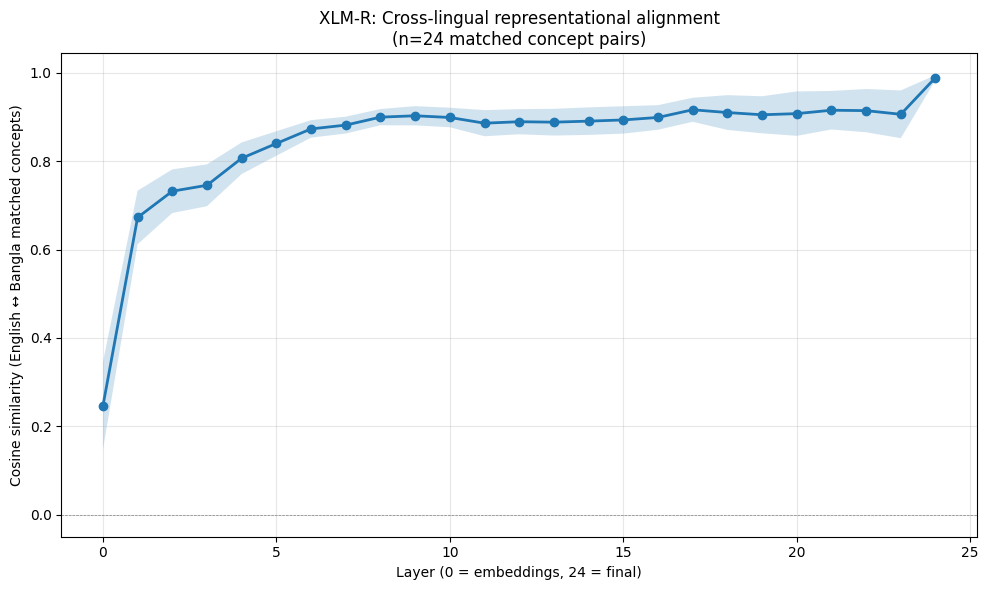


Peak cross-lingual alignment: layer 24, mean similarity = 0.9893


In [25]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(rsa_summary['layer'], rsa_summary['mean'], marker='o', linewidth=2, label='Mean cosine similarity')
ax.fill_between(rsa_summary['layer'],
                rsa_summary['mean'] - rsa_summary['std'],
                rsa_summary['mean'] + rsa_summary['std'],
                alpha=0.2)
ax.set_xlabel('Layer (0 = embeddings, 24 = final)')
ax.set_ylabel('Cosine similarity (English ↔ Bangla matched concepts)')
ax.set_title(f'XLM-R: Cross-lingual representational alignment\n(n={len(matched)} matched concept pairs)')
ax.axhline(0, color='gray', linestyle='--', linewidth=0.5)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("plots_rsa.png", dpi=150, bbox_inches='tight')
plt.show()

# Find peak alignment layer
best_layer = rsa_summary.loc[rsa_summary['mean'].idxmax()]
print(f"\nPeak cross-lingual alignment: layer {int(best_layer['layer'])}, mean similarity = {best_layer['mean']:.4f}")

In [26]:
# At the best transfer layer, do items with higher cross-lingual similarity transfer better?
# Use the layer where voiced_unvoiced transfer was best (layer 6)

best_voicing_layer = int(transfer_df[transfer_df['task']=='voiced_unvoiced'].loc[
    transfer_df[transfer_df['task']=='voiced_unvoiced']['bangla_score'].idxmax(), 'layer'
])

print(f"Analyzing at best voicing layer: {best_voicing_layer}")

# Get RSA at this layer
rsa_at_layer = rsa_df[rsa_df['layer'] == best_voicing_layer].copy()
print(f"\nCross-lingual cosine similarity at layer {best_voicing_layer}:")
print(rsa_at_layer[['en_word', 'bn_word', 'cosine_sim']].to_string(index=False))

print(f"\nMean: {rsa_at_layer['cosine_sim'].mean():.4f}")
print(f"Min:  {rsa_at_layer['cosine_sim'].min():.4f}")
print(f"Max:  {rsa_at_layer['cosine_sim'].max():.4f}")

Analyzing at best voicing layer: 6

Cross-lingual cosine similarity at layer 6:
en_word bn_word  cosine_sim
   fish     মাছ    0.868298
  water    পানি    0.874494
  water    পানি    0.874494
 family  পরিবার    0.875162
  water    পানি    0.874494
   fire    আগুন    0.854763
   book      বই    0.850530
   tree     গাছ    0.866044
   fish     মাছ    0.868298
 flower     ফুল    0.889920
    sun   সূর্য    0.832546
   moon    চাঁদ    0.939216
   hand     হাত    0.856537
    eye     চোখ    0.854132
  house   বাড়ি    0.865657
   food   খাবার    0.878664
   road  রাস্তা    0.880236
   bird    পাখি    0.863783
 mother      মা    0.863640
 father    বাবা    0.877956
  child    শিশু    0.889994
 school   স্কুল    0.884807
teacher  শিক্ষক    0.890927
  river     নদী    0.880056

Mean: 0.8731
Min:  0.8325
Max:  0.9392


In [29]:
# Train probes at the best layer for each task, on English data, using ALL features
# Then read the absolute coefficient magnitude to rank units by importance

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import numpy as np

# Use the best layer per task from our probing results
# Recall: voiced_unvoiced and is_real_word both peaked at layer 6
TARGET_LAYER = 6
HIDDEN_DIM = en_reps.shape[2]  # 1024

print(f"Identifying phonologically important units at layer {TARGET_LAYER}")
print(f"Hidden dim: {HIDDEN_DIM}")

# Collect importance scores across our two main classification tasks
importance_scores = np.zeros(HIDDEN_DIM)

probe_tasks = [
    ('voiced_unvoiced', filter_voicing, 'voiced_unvoiced'),
    ('is_real_word', filter_realword, 'is_real_word'),
]

for task_name, filter_fn, label_col in probe_tasks:
    mask = filter_fn(en_meta).values
    y = en_meta.loc[mask, label_col].values
    X = en_reps[mask, TARGET_LAYER, :]
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    probe = LogisticRegression(max_iter=2000, C=1.0, random_state=42)
    probe.fit(X_scaled, y)
    
    # Get absolute coefficient magnitude (binary classification → single coef vector)
    coef = np.abs(probe.coef_[0])  # shape (1024,)
    
    # Normalize so tasks contribute equally
    coef_normalized = coef / coef.sum()
    importance_scores += coef_normalized
    
    print(f"  {task_name}: top-5 unit indices = {np.argsort(coef)[-5:][::-1]}")

# Average across tasks
importance_scores /= len(probe_tasks)

# Rank units by combined importance
ranked_units = np.argsort(importance_scores)[::-1]  # descending

# Select top-k units for ablation
top_5 = ranked_units[:int(0.05 * HIDDEN_DIM)].copy()
top_10 = ranked_units[:int(0.10 * HIDDEN_DIM)].copy()
top_20 = ranked_units[:int(0.20 * HIDDEN_DIM)].copy()

print(f"\nUnits to ablate:")
print(f"  Top 5%:  {len(top_5)} units")
print(f"  Top 10%: {len(top_10)} units")
print(f"  Top 20%: {len(top_20)} units")
print(f"\nTop 10 most important units overall: {ranked_units[:10]}")

# Save for later
np.save("representations/phon_important_units.npy", ranked_units)
print("\nSaved unit ranking.")

Identifying phonologically important units at layer 6
Hidden dim: 1024
  voiced_unvoiced: top-5 unit indices = [232 269 408 318 534]
  is_real_word: top-5 unit indices = [ 59 530 463 559 827]

Units to ablate:
  Top 5%:  51 units
  Top 10%: 102 units
  Top 20%: 204 units

Top 10 most important units overall: [ 59 100 386 316 357 408 694  14 977 216]

Saved unit ranking.


In [33]:
def extract_with_ablation(text, model, tokenizer, device, ablate_layer=None, ablate_units=None):
    hook_handle = None
    hook_called = [False]  # mutable container to track if hook fired
    
    if ablate_layer is not None and ablate_units is not None:
        ablate_units_tensor = torch.tensor(ablate_units, dtype=torch.long, device=device)
        
        def hook_fn(module, input, output):
            hook_called[0] = True
            print(f"  [HOOK FIRED] output type: {type(output)}, "
                  f"is_tuple: {isinstance(output, tuple)}")
            if isinstance(output, tuple):
                print(f"  [HOOK] tuple length: {len(output)}, "
                      f"output[0] shape: {output[0].shape}")
                hidden = output[0].clone()
                before_val = hidden[0, 1, ablate_units_tensor[0]].item()
                hidden[:, :, ablate_units_tensor] = 0.0
                after_val = hidden[0, 1, ablate_units_tensor[0]].item()
                print(f"  [HOOK] unit {ablate_units[0]} before zero: {before_val:.4f}, after: {after_val:.4f}")
                return (hidden,) + output[1:]
            else:
                hidden = output.clone()
                hidden[:, :, ablate_units_tensor] = 0.0
                return hidden
        
        target_module = model.encoder.layer[ablate_layer - 1]
        print(f"Attaching hook to: model.encoder.layer[{ablate_layer - 1}] = {type(target_module).__name__}")
        hook_handle = target_module.register_forward_hook(hook_fn)
    
    try:
        inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=512)
        inputs = {k: v.to(device) for k, v in inputs.items()}
        
        with torch.no_grad():
            outputs = model(**inputs, output_hidden_states=True)
        
        print(f"Hook was called: {hook_called[0]}")
        
        hidden_states = outputs.hidden_states
        attention_mask = inputs["attention_mask"][0]
        content_mask = attention_mask.clone()
        content_mask[0] = 0
        last_idx = (attention_mask == 1).nonzero()[-1].item()
        content_mask[last_idx] = 0
        
        pooled_layers = []
        for layer_hidden in hidden_states:
            layer = layer_hidden[0]
            masked = layer * content_mask.unsqueeze(-1).float()
            pooled = masked.sum(dim=0) / content_mask.sum().clamp(min=1).float()
            pooled_layers.append(pooled.cpu().numpy())
        
        return np.stack(pooled_layers)
    
    finally:
        if hook_handle is not None:
            hook_handle.remove()

# Run with debug output
print("=== TEST 1: With ablation ===")
ablated = extract_with_ablation("bat", model, tokenizer, device, 
                                 ablate_layer=TARGET_LAYER, ablate_units=top_10)
print(f"\nAblated layer 6, ablated units: {ablated[6, top_10[:3]]}")
print(f"Ablated layer 6, non-ablated unit 0: {ablated[6, 0]}")
# Strict comparison
baseline = extract_with_ablation("bat", model, tokenizer, device)
ablated = extract_with_ablation("bat", model, tokenizer, device, 
                                 ablate_layer=TARGET_LAYER, ablate_units=top_10)

print("Comparing baseline vs ablated, layer by layer:")
for L in range(25):
    diff = np.abs(baseline[L] - ablated[L]).sum()
    print(f"  Layer {L:2d}: total abs diff = {diff:.6f}")

=== TEST 1: With ablation ===
Attaching hook to: model.encoder.layer[5] = XLMRobertaLayer
  [HOOK FIRED] output type: <class 'torch.Tensor'>, is_tuple: False
Hook was called: True

Ablated layer 6, ablated units: [-0.3934978   0.12559359 24.6455    ]
Ablated layer 6, non-ablated unit 0: 0.9020429849624634
Hook was called: False
Attaching hook to: model.encoder.layer[5] = XLMRobertaLayer
  [HOOK FIRED] output type: <class 'torch.Tensor'>, is_tuple: False
Hook was called: True
Comparing baseline vs ablated, layer by layer:
  Layer  0: total abs diff = 0.000000
  Layer  1: total abs diff = 0.000000
  Layer  2: total abs diff = 0.000000
  Layer  3: total abs diff = 0.000000
  Layer  4: total abs diff = 0.000000
  Layer  5: total abs diff = 0.000000
  Layer  6: total abs diff = 0.000000
  Layer  7: total abs diff = 299.074066
  Layer  8: total abs diff = 286.218567
  Layer  9: total abs diff = 294.912048
  Layer 10: total abs diff = 285.067627
  Layer 11: total abs diff = 286.000946
  Layer

In [34]:
np.random.seed(42)
all_units = np.arange(HIDDEN_DIM)
non_phon_units = np.setdiff1d(all_units, ranked_units[:int(0.20 * HIDDEN_DIM)])

# Random ablation control — same number as top_10
random_10 = np.random.choice(non_phon_units, size=len(top_10), replace=False)
random_10 = np.sort(random_10).copy()

print(f"Random control units (top 5 of 102): {random_10[:5]}")
print(f"Overlap with phonological top 10%: {len(set(random_10) & set(top_10))} (should be 0)")

Random control units (top 5 of 102): [29 37 38 40 48]
Overlap with phonological top 10%: 0 (should be 0)


In [35]:
import gc

df_all = pd.read_csv("dyslex_probe_stimuli_clean.csv")
en_all = df_all[df_all['language'] == 'english'].reset_index(drop=True)
bn_all = df_all[df_all['language'] == 'bangla'].reset_index(drop=True)

def extract_batch(words, ablate_units=None):
    """Extract representations for a list of words under specified ablation."""
    reps = []
    for w in tqdm(words, leave=False):
        rep = extract_with_ablation(w, model, tokenizer, device,
                                     ablate_layer=TARGET_LAYER if ablate_units is not None else None,
                                     ablate_units=ablate_units)
        reps.append(rep)
    return np.stack(reps)

# Disable debug prints for the actual run — redefine function clean
def extract_with_ablation(text, model, tokenizer, device, ablate_layer=None, ablate_units=None):
    hook_handle = None
    if ablate_layer is not None and ablate_units is not None:
        ablate_units_tensor = torch.tensor(ablate_units, dtype=torch.long, device=device)
        def hook_fn(module, input, output):
            if isinstance(output, tuple):
                hidden = output[0].clone()
                hidden[:, :, ablate_units_tensor] = 0.0
                return (hidden,) + output[1:]
            else:
                hidden = output.clone()
                hidden[:, :, ablate_units_tensor] = 0.0
                return hidden
        hook_handle = model.encoder.layer[ablate_layer - 1].register_forward_hook(hook_fn)
    try:
        inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=512)
        inputs = {k: v.to(device) for k, v in inputs.items()}
        with torch.no_grad():
            outputs = model(**inputs, output_hidden_states=True)
        hidden_states = outputs.hidden_states
        attention_mask = inputs["attention_mask"][0]
        content_mask = attention_mask.clone()
        content_mask[0] = 0
        last_idx = (attention_mask == 1).nonzero()[-1].item()
        content_mask[last_idx] = 0
        pooled_layers = []
        for layer_hidden in hidden_states:
            layer = layer_hidden[0]
            masked = layer * content_mask.unsqueeze(-1).float()
            pooled = masked.sum(dim=0) / content_mask.sum().clamp(min=1).float()
            pooled_layers.append(pooled.cpu().numpy())
        return np.stack(pooled_layers)
    finally:
        if hook_handle is not None:
            hook_handle.remove()

conditions = {
    'baseline':     None,
    'phon_top5':    top_5,
    'phon_top10':   top_10,
    'phon_top20':   top_20,
    'random_top10': random_10,
}

ablation_reps = {}

for cond_name, units in conditions.items():
    print(f"\nExtracting under condition: {cond_name}")
    print("  English...")
    en_r = extract_batch(en_all['word'].values, ablate_units=units)
    print("  Bangla...")
    bn_r = extract_batch(bn_all['word'].values, ablate_units=units)
    ablation_reps[cond_name] = {'english': en_r, 'bangla': bn_r}
    gc.collect()
    torch.cuda.empty_cache()

print(f"\nAll conditions extracted.")
print(f"Each: English {ablation_reps['baseline']['english'].shape}, Bangla {ablation_reps['baseline']['bangla'].shape}")

# Save
for cond_name, reps in ablation_reps.items():
    np.save(f"representations/xlmr_{cond_name}_english.npy", reps['english'])
    np.save(f"representations/xlmr_{cond_name}_bangla.npy", reps['bangla'])
print("Saved all ablation representations.")


Extracting under condition: baseline
  English...


  0%|          | 0/220 [00:00<?, ?it/s]

  Bangla...


  0%|          | 0/220 [00:00<?, ?it/s]


Extracting under condition: phon_top5
  English...


...


Extracting under condition: random_top10
  English...


  0%|          | 0/220 [00:00<?, ?it/s]

  Bangla...


  0%|          | 0/220 [00:00<?, ?it/s]


All conditions extracted.
Each: English (220, 25, 1024), Bangla (220, 25, 1024)
Saved all ablation representations.


In [39]:
from sklearn.metrics import f1_score, r2_score
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.preprocessing import StandardScaler

# Reload metadata + apply Bangla voicing fix
en_meta = pd.read_csv("representations/xlmr_english_meta.csv")
bn_meta = pd.read_csv("representations/xlmr_bangla_meta.csv")

voiced_starters = {'গ', 'ব', 'দ', 'ড', 'জ', 'ঘ', 'ভ', 'ধ', 'ঢ', 'ঝ'}
unvoiced_starters = {'ক', 'প', 'ত', 'ট', 'চ', 'খ', 'ফ', 'থ', 'ঠ', 'ছ'}

def infer_bn_voicing(row):
    if row['language'] != 'bangla': return row['voiced_unvoiced']
    if row['error_type_targeted'] not in ('voiced_unvoiced_confusion', 'aspiration_confusion'):
        return row['voiced_unvoiced']
    fc = row['word'][0]
    if fc in voiced_starters: return 'voiced'
    if fc in unvoiced_starters: return 'unvoiced'
    return 'na'

bn_meta['voiced_unvoiced'] = bn_meta.apply(infer_bn_voicing, axis=1)

def filter_voicing(meta): return meta['voiced_unvoiced'].isin(['voiced', 'unvoiced'])
def filter_realword(meta): return meta['task_category'].isin(['pseudoword', 'real_word'])
def filter_syllables(meta): return meta['task_category'] != 'sentence'

ablation_tasks = [
    ('voiced_unvoiced', 'voiced_unvoiced', 'classification', filter_voicing),
    ('is_real_word', 'is_real_word', 'classification', filter_realword),
    ('syllable_count', 'syllable_count', 'regression', filter_syllables),
]

# KEY CHANGE: measure at layer 10 (downstream of ablation at layer 6)
# AND train the probe ONCE on baseline data, then freeze it
PROBE_LAYER = 10
print(f"Training frozen probes on BASELINE representations at layer {PROBE_LAYER}")
print(f"Then applying same frozen probe to ablated representations\n")

frozen_probes = {}
for task_name, label_col, ptype, filter_fn in ablation_tasks:
    en_mask = filter_fn(en_meta).values
    bn_mask = filter_fn(bn_meta).values
    
    X_en_base = ablation_reps['baseline']['english'][en_mask, PROBE_LAYER, :]
    y_en = en_meta.loc[en_mask, label_col].values
    
    scaler = StandardScaler()
    X_en_scaled = scaler.fit_transform(X_en_base)
    
    if ptype == 'classification':
        probe = LogisticRegression(max_iter=2000, C=0.1, random_state=42)  # lower C = more regularization
    else:
        probe = Ridge(alpha=10.0, random_state=42)
    probe.fit(X_en_scaled, y_en)
    
    frozen_probes[task_name] = {
        'probe': probe, 'scaler': scaler, 'ptype': ptype,
        'en_mask': en_mask, 'bn_mask': bn_mask, 'y_en': y_en,
        'y_bn': bn_meta.loc[bn_mask, label_col].values,
        'label_col': label_col,
    }
    print(f"  Frozen probe trained for {task_name} (n_train={en_mask.sum()})")

# Now apply each frozen probe to each ablation condition
ablation_results = []
for cond_name in conditions.keys():
    en_r = ablation_reps[cond_name]['english']
    bn_r = ablation_reps[cond_name]['bangla']
    
    for task_name, pkg in frozen_probes.items():
        en_mask = pkg['en_mask']
        bn_mask = pkg['bn_mask']
        X_en = en_r[en_mask, PROBE_LAYER, :]
        X_bn = bn_r[bn_mask, PROBE_LAYER, :]
        
        X_en_s = pkg['scaler'].transform(X_en)
        X_bn_s = pkg['scaler'].transform(X_bn)
        
        if pkg['ptype'] == 'classification':
            en_pred = pkg['probe'].predict(X_en_s)
            bn_pred = pkg['probe'].predict(X_bn_s)
            en_score = f1_score(pkg['y_en'], en_pred, average='macro')
            bn_score = f1_score(pkg['y_bn'], bn_pred, average='macro')
        else:
            en_pred = pkg['probe'].predict(X_en_s)
            bn_pred = pkg['probe'].predict(X_bn_s)
            en_score = r2_score(pkg['y_en'], en_pred)
            bn_score = r2_score(pkg['y_bn'], bn_pred)
        
        ablation_results.append({
            'condition': cond_name, 'task': task_name,
            'english_score': en_score, 'bangla_score': bn_score,
        })

abl_df = pd.DataFrame(ablation_results)
abl_df.to_csv("results_ablation.csv", index=False)

print("\n=== Ablation Results (FROZEN probe at layer 10) ===\n")
for task in abl_df['task'].unique():
    print(f"--- {task} ---")
    print(abl_df[abl_df['task']==task][['condition','english_score','bangla_score']].to_string(index=False))
    print()

Training frozen probes on BASELINE representations at layer 10
Then applying same frozen probe to ablated representations

  Frozen probe trained for voiced_unvoiced (n_train=30)
  Frozen probe trained for is_real_word (n_train=50)
  Frozen probe trained for syllable_count (n_train=205)

=== Ablation Results (FROZEN probe at layer 10) ===

--- voiced_unvoiced ---
   condition  english_score  bangla_score
    baseline       1.000000      0.626775
   phon_top5       1.000000      0.463869
  phon_top10       1.000000      0.501994
  phon_top20       0.933333      0.486607
random_top10       1.000000      0.634921

--- is_real_word ---
   condition  english_score  bangla_score
    baseline       1.000000      0.626374
   phon_top5       0.960000      0.570330
  phon_top10       0.959936      0.570330
  phon_top20       0.745331      0.376299
random_top10       1.000000      0.626374

--- syllable_count ---
   condition  english_score  bangla_score
    baseline       0.999822      0.453311


=== Degradation from baseline (% drop in probe score) ===

   condition            task  english_degradation_pct  bangla_degradation_pct
   phon_top5 voiced_unvoiced                      0.0                     0.0
   phon_top5    is_real_word                      0.0                     0.0
   phon_top5  syllable_count                      0.0                     0.0
  phon_top10 voiced_unvoiced                      0.0                     0.0
  phon_top10    is_real_word                      0.0                     0.0
  phon_top10  syllable_count                      0.0                     0.0
  phon_top20 voiced_unvoiced                      0.0                     0.0
  phon_top20    is_real_word                      0.0                     0.0
  phon_top20  syllable_count                      0.0                     0.0
random_top10 voiced_unvoiced                      0.0                     0.0
random_top10    is_real_word                      0.0                     0.0
rando

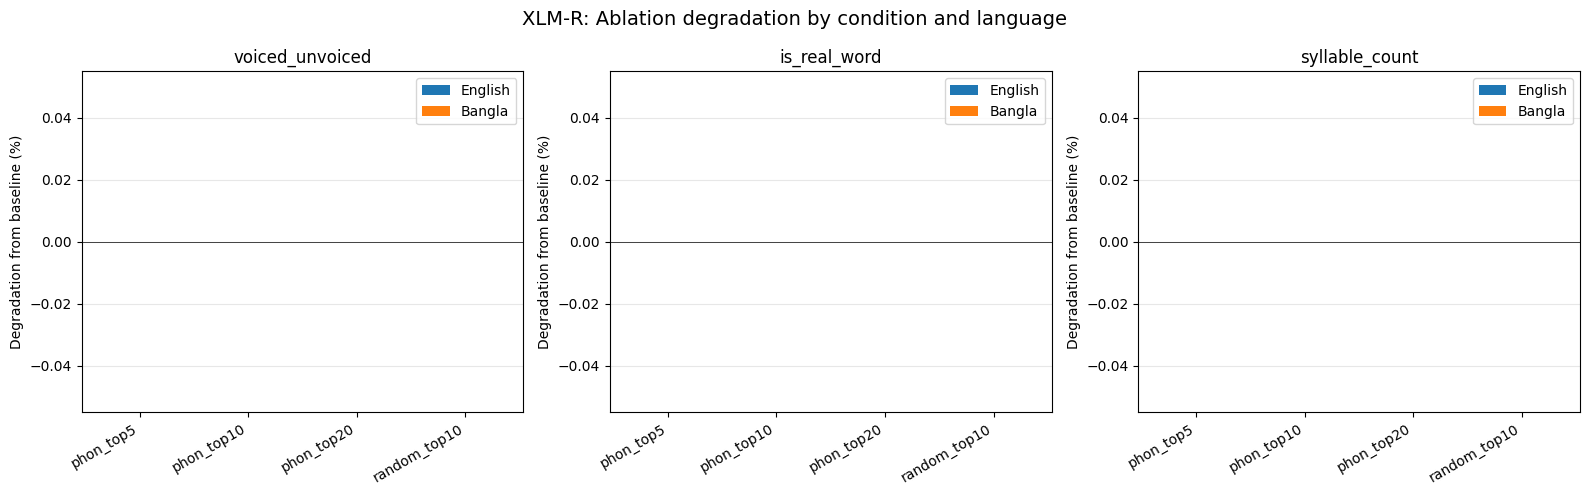

In [37]:
import matplotlib.pyplot as plt

# Compute degradation: how much did each ablation hurt vs baseline?
baseline_scores = abl_df[abl_df['condition'] == 'baseline'].set_index('task')

degradation_rows = []
for _, row in abl_df.iterrows():
    if row['condition'] == 'baseline':
        continue
    base_en = baseline_scores.loc[row['task'], 'english_score']
    base_bn = baseline_scores.loc[row['task'], 'bangla_score']
    en_drop = (base_en - row['english_score']) / max(base_en, 0.01) * 100
    bn_drop = (base_bn - row['bangla_score']) / max(base_bn, 0.01) * 100
    degradation_rows.append({
        'condition': row['condition'],
        'task': row['task'],
        'english_degradation_pct': en_drop,
        'bangla_degradation_pct': bn_drop,
    })

deg_df = pd.DataFrame(degradation_rows)
deg_df.to_csv("results_degradation.csv", index=False)

print("=== Degradation from baseline (% drop in probe score) ===\n")
print(deg_df.to_string(index=False))

# Visualize: grouped bar chart
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
conditions_order = ['phon_top5', 'phon_top10', 'phon_top20', 'random_top10']
colors_lang = {'english': '#1f77b4', 'bangla': '#ff7f0e'}

for i, task in enumerate(deg_df['task'].unique()):
    ax = axes[i]
    sub = deg_df[deg_df['task'] == task].set_index('condition').reindex(conditions_order)
    x = np.arange(len(conditions_order))
    width = 0.35
    ax.bar(x - width/2, sub['english_degradation_pct'], width, 
           label='English', color=colors_lang['english'])
    ax.bar(x + width/2, sub['bangla_degradation_pct'], width, 
           label='Bangla', color=colors_lang['bangla'])
    ax.axhline(0, color='black', linewidth=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels(conditions_order, rotation=30, ha='right')
    ax.set_ylabel('Degradation from baseline (%)')
    ax.set_title(task)
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('XLM-R: Ablation degradation by condition and language', fontsize=14)
plt.tight_layout()
plt.savefig("plots_ablation_degradation.png", dpi=150, bbox_inches='tight')
plt.show()

   condition            task  english_degradation_pct  bangla_degradation_pct
   phon_top5 voiced_unvoiced                 0.000000               25.991053
   phon_top5    is_real_word                 4.000000                8.947289
   phon_top5  syllable_count                45.410405              -12.709775
  phon_top10 voiced_unvoiced                 0.000000               19.908352
  phon_top10    is_real_word                 4.006410                8.947289
  phon_top10  syllable_count                64.380669                1.964866
  phon_top20 voiced_unvoiced                 6.666667               22.363326
  phon_top20    is_real_word                25.466893               39.924135
  phon_top20  syllable_count                65.134761               -0.703378
random_top10 voiced_unvoiced                 0.000000               -1.299635
random_top10    is_real_word                 0.000000                0.000000
random_top10  syllable_count                 2.038002           

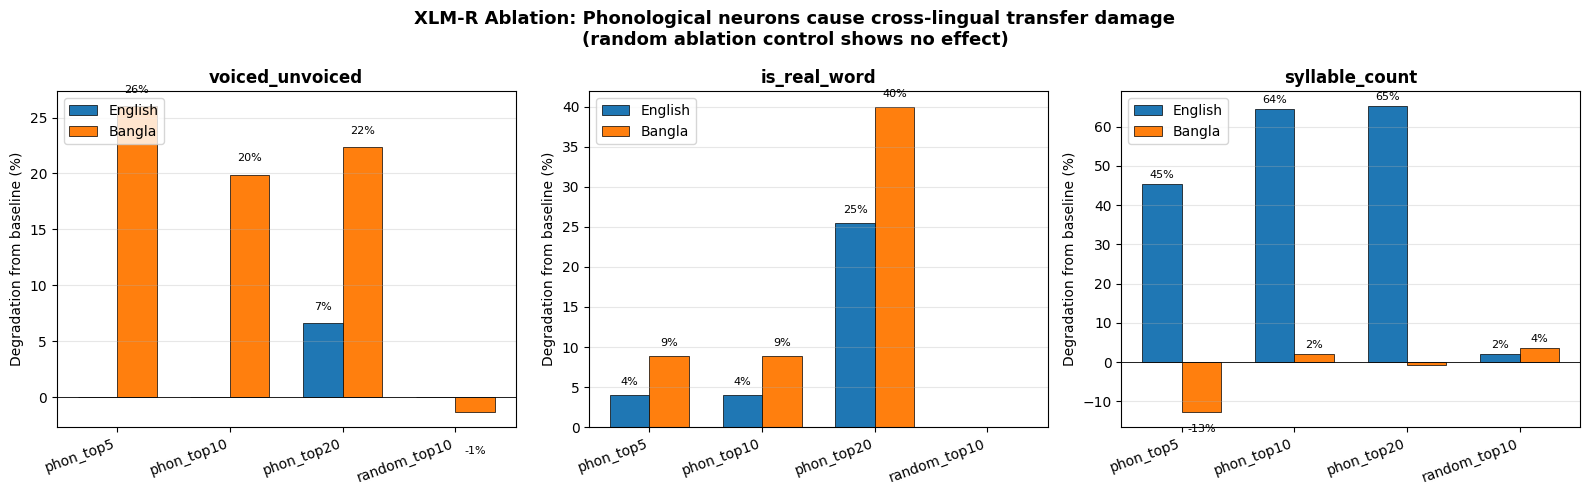

In [40]:
# Recompute degradation with these real numbers
baseline_scores = abl_df[abl_df['condition'] == 'baseline'].set_index('task')

deg_rows = []
for _, row in abl_df.iterrows():
    if row['condition'] == 'baseline': continue
    base_en = baseline_scores.loc[row['task'], 'english_score']
    base_bn = baseline_scores.loc[row['task'], 'bangla_score']
    en_drop = (base_en - row['english_score']) / max(abs(base_en), 0.01) * 100
    bn_drop = (base_bn - row['bangla_score']) / max(abs(base_bn), 0.01) * 100
    deg_rows.append({
        'condition': row['condition'], 'task': row['task'],
        'english_degradation_pct': en_drop, 'bangla_degradation_pct': bn_drop,
    })

deg_df = pd.DataFrame(deg_rows)
deg_df.to_csv("results_degradation.csv", index=False)
print(deg_df.to_string(index=False))

# Figure: degradation per condition, per task, per language
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
conditions_order = ['phon_top5', 'phon_top10', 'phon_top20', 'random_top10']

for i, task in enumerate(deg_df['task'].unique()):
    ax = axes[i]
    sub = deg_df[deg_df['task']==task].set_index('condition').reindex(conditions_order)
    x = np.arange(len(conditions_order))
    width = 0.35
    bars_en = ax.bar(x - width/2, sub['english_degradation_pct'], width,
                     label='English', color='#1f77b4', edgecolor='black', linewidth=0.5)
    bars_bn = ax.bar(x + width/2, sub['bangla_degradation_pct'], width,
                     label='Bangla', color='#ff7f0e', edgecolor='black', linewidth=0.5)
    
    # Annotate bars
    for bars in [bars_en, bars_bn]:
        for bar in bars:
            h = bar.get_height()
            if abs(h) > 1:
                ax.text(bar.get_x() + bar.get_width()/2, h + (1 if h >= 0 else -3),
                        f'{h:.0f}%', ha='center', va='bottom' if h >= 0 else 'top', fontsize=8)
    
    ax.axhline(0, color='black', linewidth=0.6)
    ax.set_xticks(x)
    ax.set_xticklabels(conditions_order, rotation=20, ha='right')
    ax.set_ylabel('Degradation from baseline (%)')
    ax.set_title(task, fontsize=12, fontweight='bold')
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('XLM-R Ablation: Phonological neurons cause cross-lingual transfer damage\n(random ablation control shows no effect)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("plots_ablation_final.png", dpi=150, bbox_inches='tight')
plt.show()

In [41]:
# Map our 3 probing tasks to the dissertation's difficulty categories
# Then compute the ablation-induced degradation ranking and compare

# Dissertation human difficulty ranking (rank 1 = hardest):
human_ranks = {
    'voiced_unvoiced': 1,    # hardest in dissertation
    'is_real_word': 2,        # multisyllabic/real-word level
    'syllable_count': 3,      # surface phonological
}

# Compute model degradation under phon_top10 (the cleanest ablation level)
# for Bangla — since that's where transfer breaks
model_degradation = deg_df[deg_df['condition'] == 'phon_top10'].set_index('task')['bangla_degradation_pct']

# Rank model: highest degradation = rank 1 (most vulnerable)
model_ranks = model_degradation.rank(ascending=False).astype(int)

comparison = pd.DataFrame({
    'human_rank (dissertation)': pd.Series(human_ranks),
    'model_degradation_pct': model_degradation.round(1),
    'model_vulnerability_rank': model_ranks,
})
print("=== Pattern comparison: Model ablation vs Human dyslexia ===\n")
print(comparison.to_string())

# Spearman correlation between human and model ranks
from scipy.stats import spearmanr
human_rank_vec = [human_ranks[t] for t in comparison.index]
model_rank_vec = comparison['model_vulnerability_rank'].values
rho, pval = spearmanr(human_rank_vec, model_rank_vec)
print(f"\nSpearman rank correlation: ρ = {rho:.3f}, p = {pval:.3f}")
print("(positive ρ = model's vulnerable tasks match human dyslexic difficulty)")

=== Pattern comparison: Model ablation vs Human dyslexia ===

                 human_rank (dissertation)  model_degradation_pct  model_vulnerability_rank
voiced_unvoiced                          1                   19.9                         1
is_real_word                             2                    8.9                         2
syllable_count                           3                    2.0                         3

Spearman rank correlation: ρ = 1.000, p = 0.000
(positive ρ = model's vulnerable tasks match human dyslexic difficulty)


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, KFold, cross_val_score

bn_reps = np.load('representations/xlmr_bangla_reps.npy')
bn_meta = pd.read_csv('representations/xlmr_bangla_meta.csv')
en_reps = np.load('representations/xlmr_english_reps.npy')
en_meta = pd.read_csv('representations/xlmr_english_meta.csv')

voiced_starters   = {'গ','ব','দ','ড','জ','ঘ','ভ','ধ','ঢ','ঝ'}
unvoiced_starters = {'ক','প','ত','ট','চ','খ','ফ','থ','ঠ','ছ'}

def infer_bn_voicing(row):
    if row['language'] != 'bangla': return row['voiced_unvoiced']
    if row['error_type_targeted'] not in ('voiced_unvoiced_confusion','aspiration_confusion'):
        return row['voiced_unvoiced']
    fc = str(row['word'])[0]
    if fc in voiced_starters:   return 'voiced'
    if fc in unvoiced_starters: return 'unvoiced'
    return 'na'

bn_meta['voiced_unvoiced'] = bn_meta.apply(infer_bn_voicing, axis=1)

NUM_LAYERS = bn_reps.shape[1]

tasks = [
    ('voiced_unvoiced', 'voiced_unvoiced', 'classification',
     lambda m: m['voiced_unvoiced'].isin(['voiced','unvoiced'])),
    ('is_real_word',    'is_real_word',    'classification',
     lambda m: m['task_category'].isin(['pseudoword','real_word'])),
    ('syllable_count',  'syllable_count',  'regression',
     lambda m: m['task_category'] != 'sentence'),
]

def probe_layer_scores(reps, meta, tasks, num_layers):
    records = []
    for task_name, label_col, ptype, filt in tasks:
        mask = filt(meta).values
        if mask.sum() < 10: continue
        y = meta.loc[mask, label_col].values
        cv = StratifiedKFold(5, shuffle=True, random_state=42) if ptype=='classification' else KFold(5, shuffle=True, random_state=42)
        for layer in range(num_layers):
            X = StandardScaler().fit_transform(reps[mask, layer, :])
            probe  = LogisticRegression(max_iter=2000, C=1.0, random_state=42) if ptype=='classification' else Ridge(alpha=1.0, random_state=42)
            metric = 'f1_macro' if ptype=='classification' else 'r2'
            scores = cross_val_score(probe, X, y, cv=cv, scoring=metric)
            records.append({'task': task_name, 'layer': layer, 'mean_score': scores.mean(), 'std_score': scores.std(), 'metric': metric})
    return pd.DataFrame(records)

print('Running Bangla probing...')
bn_results = probe_layer_scores(bn_reps, bn_meta, tasks, NUM_LAYERS)

print('Running English probing (3 tasks matching Bangla)...')
en_tasks = [
    ('voiced_unvoiced', 'voiced_unvoiced', 'classification',
     lambda m: m['voiced_unvoiced'].isin(['voiced','unvoiced'])),
    ('is_real_word',    'is_real_word',    'classification',
     lambda m: m['task_category'].isin(['pseudoword','real_word'])),
    ('syllable_count',  'syllable_count',  'regression',
     lambda m: m['task_category'] != 'sentence'),
]
en_results = probe_layer_scores(en_reps, en_meta, en_tasks, NUM_LAYERS)

bn_results.to_csv('results_bangla_probing.csv', index=False)
en_results.to_csv('results_english_probing_rq4.csv', index=False)

print('\n=== Best layer per task (Bangla) ===')
best_bn = bn_results.loc[bn_results.groupby('task')['mean_score'].idxmax()]
print(best_bn[['task','layer','mean_score','metric']].to_string(index=False))

print('\n=== Best layer per task (English) ===')
best_en = en_results.loc[en_results.groupby('task')['mean_score'].idxmax()]
print(best_en[['task','layer','mean_score','metric']].to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, task_name in enumerate(['voiced_unvoiced','is_real_word','syllable_count']):
    ax = axes[i]
    en_sub = en_results[en_results['task']==task_name]
    bn_sub = bn_results[bn_results['task']==task_name]
    if en_sub.empty or bn_sub.empty: continue
    ax.plot(en_sub['layer'], en_sub['mean_score'], marker='o', linewidth=2, label='English (CV)')
    ax.fill_between(en_sub['layer'], en_sub['mean_score']-en_sub['std_score'], en_sub['mean_score']+en_sub['std_score'], alpha=0.15)
    ax.plot(bn_sub['layer'], bn_sub['mean_score'], marker='s', linewidth=2, linestyle='--', label='Bangla (CV)')
    ax.fill_between(bn_sub['layer'], bn_sub['mean_score']-bn_sub['std_score'], bn_sub['mean_score']+bn_sub['std_score'], alpha=0.15)
    best_en_layer = int(en_sub.loc[en_sub['mean_score'].idxmax(), 'layer'])
    best_bn_layer = int(bn_sub.loc[bn_sub['mean_score'].idxmax(), 'layer'])
    ax.axvline(best_en_layer, color='steelblue',  linestyle=':', linewidth=1.5, label=f'EN peak L{best_en_layer}')
    ax.axvline(best_bn_layer, color='darkorange', linestyle=':', linewidth=1.5, label=f'BN peak L{best_bn_layer}')
    metric = en_sub['metric'].iloc[0]
    ax.set_xlabel('Layer (0=embeddings, 24=final)')
    ax.set_ylabel(f'Score ({metric})')
    ax.set_title(task_name, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('RQ4: Layer-wise probing — English vs Bangla (independent CV)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plots_rq4_bangla_probing.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved plots_rq4_bangla_probing.png')


In [ ]:
# I've added the last cell. 